
1. IRIS DATASET RESULTS (K=5)
Accuracy Score: 1.00

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


2. DIABETES DATASET RESULTS (Scaled, K=7)
Accuracy Score: 0.68

Confusion Matrix:
 [[78 21]
 [28 27]]

3. HEART DATASET RESULTS (Optimal K=6)
Maximum Accuracy Score: 0.93


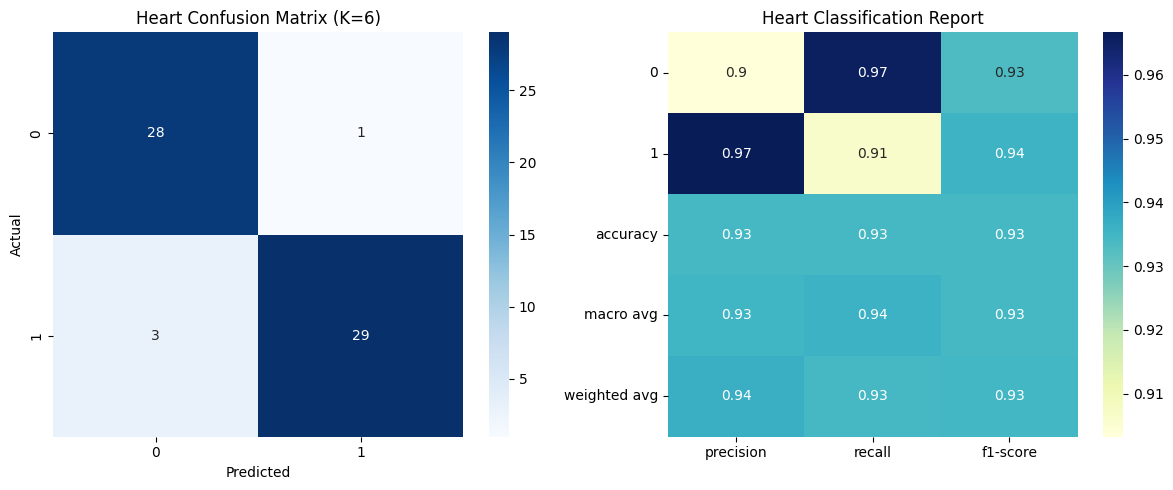

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Helper function to print headers
def print_header(text):
    print("\n" + "="*50)
    print(text)
    print("="*50)

# ---------------------------------------------------------
# 1. IRIS DATASET CLASSIFICATION
# ---------------------------------------------------------
try:
    iris_df = pd.read_csv('iris (1).csv')
    X_iris = iris_df.iloc[:, :-1]  # Features
    y_iris = iris_df.iloc[:, -1]   # Target

    X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.20, random_state=42)

    # Standard K=5 for Iris
    knn_iris = KNeighborsClassifier(n_neighbors=5)
    knn_iris.fit(X_train, y_train)
    y_pred = knn_iris.predict(X_test)

    print_header("1. IRIS DATASET RESULTS (K=5)")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

except FileNotFoundError:
    print("Error: iris.csv not found.")

# ---------------------------------------------------------
# 2. DIABETES DATASET (With Feature Scaling)
# ---------------------------------------------------------
try:
    diabetes_df = pd.read_csv('diabetes.csv')
    X_dia = diabetes_df.iloc[:, :-1]
    y_dia = diabetes_df.iloc[:, -1]

    # Feature Scaling (Crucial for Diabetes dataset)
    scaler = StandardScaler()
    X_dia_scaled = scaler.fit_transform(X_dia)

    X_train, X_test, y_train, y_test = train_test_split(X_dia_scaled, y_dia, test_size=0.20, random_state=42)

    # Choosing K=7
    knn_dia = KNeighborsClassifier(n_neighbors=7)
    knn_dia.fit(X_train, y_train)
    y_pred = knn_dia.predict(X_test)

    print_header("2. DIABETES DATASET RESULTS (Scaled, K=7)")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

except FileNotFoundError:
    print("Error: diabetes.csv not found.")

# ---------------------------------------------------------
# 3. HEART DATASET (Finding Optimal K)
# ---------------------------------------------------------
try:
    heart_df = pd.read_csv('heart.csv')
    X_h = heart_df.iloc[:, :-1]
    y_h = heart_df.iloc[:, -1]

    # Scale data for better KNN performance
    X_h = StandardScaler().fit_transform(X_h)
    X_train, X_test, y_train, y_test = train_test_split(X_h, y_h, test_size=0.20, random_state=42)

    # Finding the best K value
    scores = []
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        scores.append(knn.score(X_test, y_test))

    best_k = scores.index(max(scores)) + 1

    # Final model with best K
    knn_heart = KNeighborsClassifier(n_neighbors=best_k)
    knn_heart.fit(X_train, y_train)
    y_pred = knn_heart.predict(X_test)

    print_header(f"3. HEART DATASET RESULTS (Optimal K={best_k})")
    print(f"Maximum Accuracy Score: {max(scores):.2f}")

    # Plotting Confusion Matrix
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Heart Confusion Matrix (K={best_k})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Display Classification Report as a heatmap for visual representation
    plt.subplot(1, 2, 2)
    report = classification_report(y_test, y_pred, output_dict=True)
    sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='YlGnBu')
    plt.title("Heart Classification Report")

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: heart.csv not found.")


In [6]:
from google.colab import files

print("Please upload 'iris.csv':")
uploaded = files.upload()

Please upload 'iris.csv':


KeyboardInterrupt: 